# Titanic Survival EDA Report

## Goal

The goal of this report is to identify the strongest factors related to passenger survival on the Titanic.

This report does not check every feature. It focuses only on the most useful patterns found during exploration.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("titanic_features.csv")
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,title,title_group,age_group,fare_group,is_alone_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,Mr,Mr,Adult,Low,With family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,Mrs,Mrs,Adult,Very High,With family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,Miss,Miss,Adult,Medium,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,Mrs,Mrs,Adult,Very High,With family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,Mr,Mr,Adult,Medium,Alone


In [2]:
df.shape

(891, 18)

The dataset has 891 passengers. It includes original Titanic columns plus engineered features such as age_group, fare_group, title_group, and is_alone_label.

In [3]:
baseline_survival = df["survived"].mean() * 100
print(f"Baseline survival rate: {baseline_survival:.2f}%")

Baseline survival rate: 38.38%


The baseline survival rate is about 38%. This means most passengers did not survive, so the next step is to find which groups had better or worse survival chances.

In [4]:
def survival_rate_table(data, feature):
    result = (
        data.groupby(feature, observed=True)["survived"]
        .mean()
        .mul(100)
        .reset_index()
        .rename(columns={"survived": "survival_rate"})
    )
    return result

def plot_survival_rate(data, feature, title):
    table = survival_rate_table(data, feature)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=table, x=feature, y="survival_rate")
    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel("Survival Rate (%)")
    plt.ylim(0, 100)
    plt.show()

    return table

## Key Finding 1 - Gender

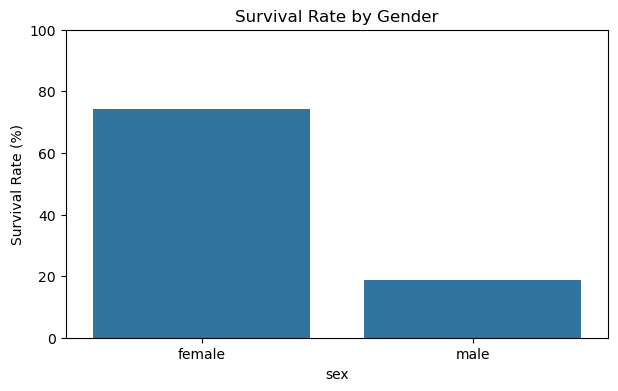

,sex,survival_rate
0,female,74.203822
1,male,18.890815


In [5]:
plot_survival_rate(df, "sex", "Survival Rate by Gender")

Gender shows one of the strongest survival patterns. Female passengers had a much higher survival rate than male passengers.

## Key Finding 2 - Passenger Class

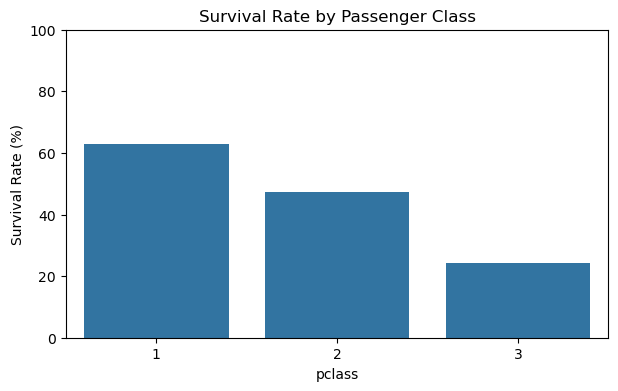

,pclass,survival_rate
0,1,62.962963
1,2,47.282609
2,3,24.236253


In [6]:
plot_survival_rate(df, "pclass", "Survival Rate by Passenger Class")

Passenger class also shows a clear survival pattern. First-class passengers had the highest survival rate, while third-class passengers had the lowest.

## Key Finding 3 - Age Group

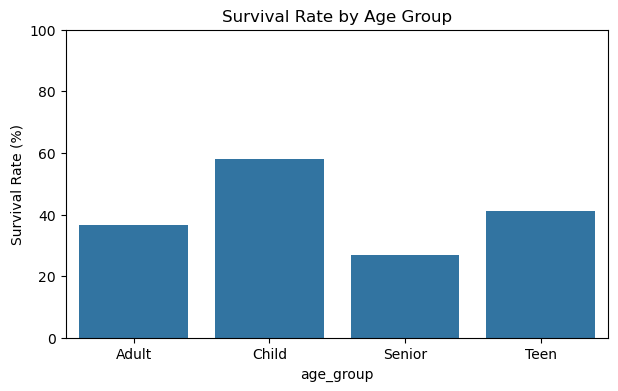

,age_group,survival_rate
0,Adult,36.519258
1,Child,57.971014
2,Senior,26.923077
3,Teen,41.052632


In [7]:
plot_survival_rate(df, "age_group", "Survival Rate by Age Group")

Children had the highest survival rate, while seniors had the lowest. This suggests age was related to survival priority.

## Key Finding 4 - Fare Group

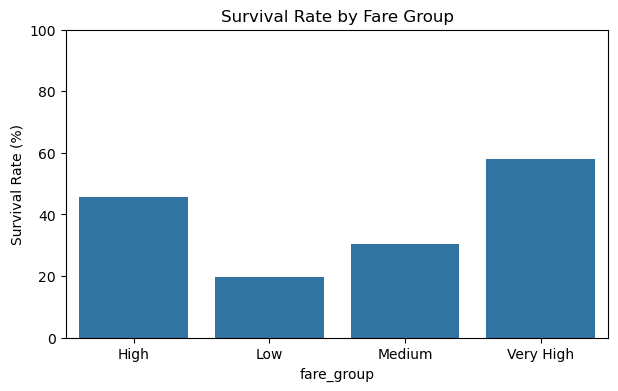

,fare_group,survival_rate
0,High,45.495495
1,Low,19.730942
2,Medium,30.357143
3,Very High,58.108108


In [8]:
plot_survival_rate(df, "fare_group", "Survival Rate by Fare Group")

Passengers in higher fare groups had higher survival rates. Fare is likely connected to passenger class, cabin location, and access to lifeboats.

## Strongest Combined Pattern - Gender + Class

In [9]:
sex_class_survival = (
    df.groupby(["pclass", "sex"], observed=True)["survived"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"survived": "survival_rate"})
)

sex_class_survival

,pclass,sex,survival_rate
0,1,female,96.808511
1,1,male,36.885246
2,2,female,92.105263
3,2,male,15.740741
4,3,female,50.000000
5,3,male,13.544669


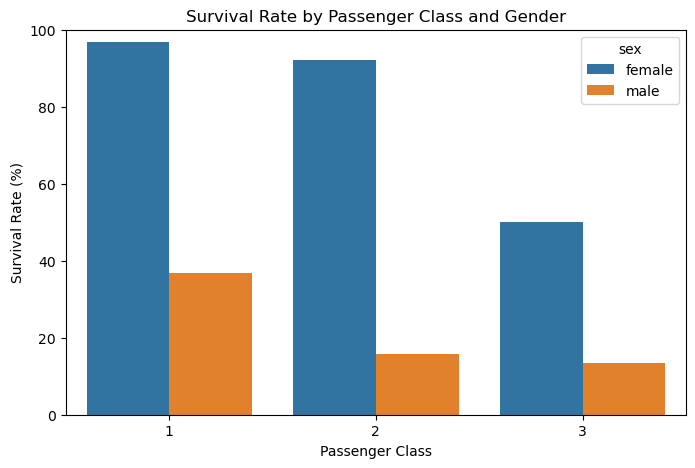

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=sex_class_survival,
    x="pclass",
    y="survival_rate",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

The strongest combined pattern is gender and class together. Female passengers had higher survival rates across classes, while male passengers in lower classes had especially low survival rates.

## Final Summary

The most important survival-related factors were gender, passenger class, age group, and fare group.

The strongest individual pattern was gender: female passengers survived at much higher rates than male passengers.

Passenger class also mattered strongly. First-class passengers had better survival rates than second- and third-class passengers.

Children had higher survival rates than adults and seniors, suggesting that age influenced survival priority.

Fare group followed a similar pattern to class. Higher fare passengers had better survival rates, likely because fare is connected to class and ship location.

Overall, survival was not random. It was strongly related to gender, class, age, and access.

## What I Learned

In this report, I learned how to turn exploratory analysis into a structured data story.

Day 3 was about checking many possible patterns. Day 4 was about selecting the strongest patterns and explaining them clearly.

I also practiced using grouped survival rates, reusable plotting functions, and visual storytelling with pandas and seaborn.